In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/1-data_wrangling-weight-height/weight-height.csv")
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [39]:
df.isnull().sum()

Index             0
Height(Inches)    0
Weight(Pounds)    0
dtype: int64

In [40]:
#if there is any missing value
df.fillna(df.median(numeric_only=True), inplace=True)
# df["Height(Inches)"] = df["Height(Inches)"].fillna(df["Height(Inches)"].median())

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [41]:
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [42]:
#if there is any negative value
df = df[
    (df["Height(Inches)"] > 0) &
    (df["Weight(Pounds)"] > 0)
]

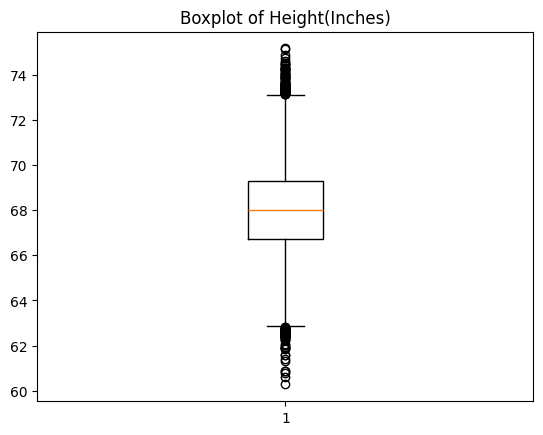

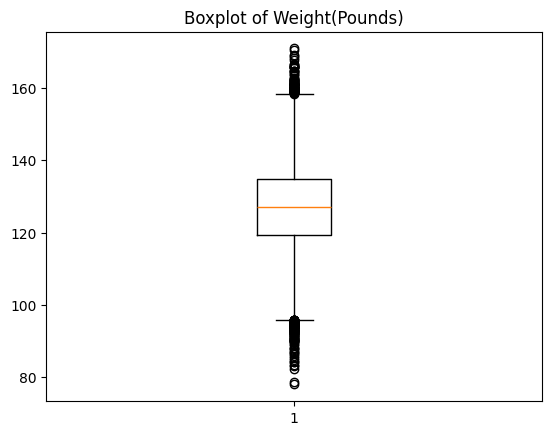

In [43]:
#numeric_cols = df.select_dtypes(include ="number").columns 
# above code also includes the index

numeric_cols = ["Height(Inches)", "Weight(Pounds)"]

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [44]:
for col in ["Height(Inches)", "Weight(Pounds)"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Height(Inches): 167 outliers
Weight(Pounds): 191 outliers


In [45]:
for col in ["Height(Inches)", "Weight(Pounds)"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower,upper)

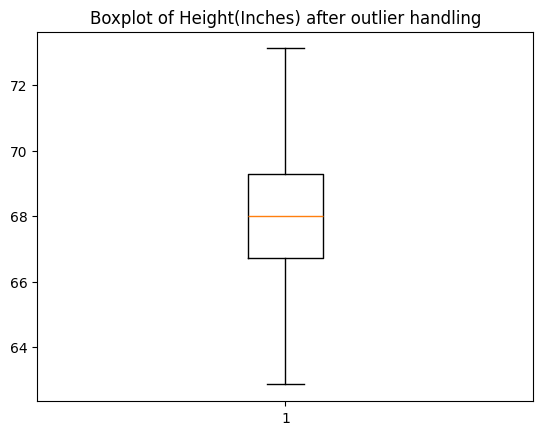

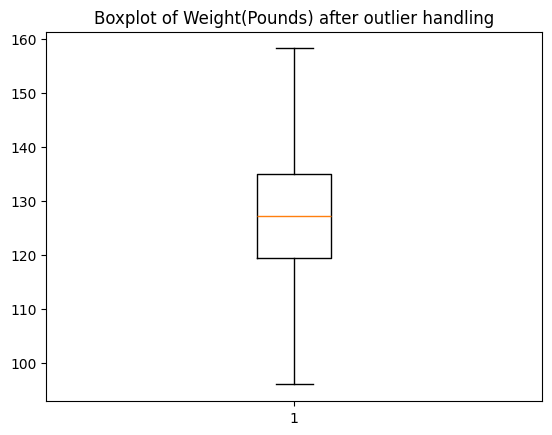

In [46]:
numeric_cols = ["Height(Inches)", "Weight(Pounds)"]

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col} after outlier handling")
    plt.show()

In [47]:
print(df["Weight(Pounds)"].skew())

-0.015479225842570762


In [53]:
# df["Weight_log"] = np.log1p(df["Weight(Pounds)"])
# only when there is a skewness
# print(df["Weight_log"].skew())

In [54]:
# after skewness improvement, check using hist
# plt.figure()
# plt.subplot(1,2,1)
# plt.hist(df["Weight(Pounds)"])
# plt.title("Before")

# plt.subplot(1,2,2)
# plt.hist(df["Weight_Log"])
# plt.title("After Log Transformation")

# plt.show()